# Homework 01: Moneyball Analysis

This notebook contains the complete analysis for the assignment. It begins by understanding the training and evaluation data, then continues through data preparation, multiple linear regression, model evaluation, and predictions.

The data represents professional baseball teams from 1871 through 2006. The assignment asks us to predict `TARGET_WINS` using the variables provided in the training data.

## Assignment goal

The goal is to understand the variables, check the quality of the data, and identify possible relationships with wins before fitting a model. The `INDEX` column is an identification variable and should not be used as a predictor.

The training data contains the response variable, `TARGET_WINS`. The evaluation data does not contain that variable and will be used later for predictions.

In [3]:
suppressPackageStartupMessages({
  library(readr)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(knitr)
})

## Load the datasets

The notebook is stored in `homeworks/hw01/notebooks/`, so the data files are one folder above in `../data/`.

In [5]:
training_path <- "../data/moneyball-training-data.csv"
evaluation_path <- "../data/moneyball-evaluation-data.csv"

training <- read_csv(training_path, show_col_types = FALSE)
evaluation <- read_csv(evaluation_path, show_col_types = FALSE)

cat("Training file loaded from:", training_path, "\n")
cat("Evaluation file loaded from:", evaluation_path, "\n")

[1] "Training file loaded from: ../data/moneyball-training-data.csv \n"
[1] "Evaluation file loaded from: ../data/moneyball-evaluation-data.csv \n"


## Dataset dimensions

The training and evaluation files should have the same predictor columns. The training file also includes `TARGET_WINS`.

In [6]:
dataset_dimensions <- tibble(
  dataset = c("Training", "Evaluation"),
  rows = c(nrow(training), nrow(evaluation)),
  columns = c(ncol(training), ncol(evaluation))
)

kable(dataset_dimensions)

cat("Training columns:\n")
names(training)

cat("Evaluation columns:\n")
names(evaluation)



|dataset    | rows| columns|
|:----------|----:|-------:|
|Training   | 2276|      17|
|Evaluation |  259|      16|

Training columns:


[1] "INDEX"            "TARGET_WINS"      "TEAM_BATTING_H"   "TEAM_BATTING_2B" 
 [5] "TEAM_BATTING_3B"  "TEAM_BATTING_HR"  "TEAM_BATTING_BB"  "TEAM_BATTING_SO" 
 [9] "TEAM_BASERUN_SB"  "TEAM_BASERUN_CS"  "TEAM_BATTING_HBP" "TEAM_PITCHING_H" 
[13] "TEAM_PITCHING_HR" "TEAM_PITCHING_BB" "TEAM_PITCHING_SO" "TEAM_FIELDING_E" 
[17] "TEAM_FIELDING_DP"

Evaluation columns:


[1] "INDEX"            "TEAM_BATTING_H"   "TEAM_BATTING_2B"  "TEAM_BATTING_3B" 
 [5] "TEAM_BATTING_HR"  "TEAM_BATTING_BB"  "TEAM_BATTING_SO"  "TEAM_BASERUN_SB" 
 [9] "TEAM_BASERUN_CS"  "TEAM_BATTING_HBP" "TEAM_PITCHING_H"  "TEAM_PITCHING_HR"
[13] "TEAM_PITCHING_BB" "TEAM_PITCHING_SO" "TEAM_FIELDING_E"  "TEAM_FIELDING_DP"

## Identify the dependent and independent variables

The dependent variable, also called the response variable, is `TARGET_WINS`. It is the number of wins we want to predict.

The independent variables are the baseball performance statistics used to explain or predict `TARGET_WINS`. `INDEX` is not an independent variable because it only identifies a row and should not be used in the model.

In [15]:
dependent_variable <- "TARGET_WINS"
independent_variables <- setdiff(
  names(training),
  c(dependent_variable, "INDEX")
)

cat("Dependent variable:\n")
print(dependent_variable)

cat("Independent variables:\n")
print(independent_variables)

Dependent variable:
[1] "TARGET_WINS"
Independent variables:
 [1] "TEAM_BATTING_H"   "TEAM_BATTING_2B"  "TEAM_BATTING_3B"  "TEAM_BATTING_HR" 
 [5] "TEAM_BATTING_BB"  "TEAM_BATTING_SO"  "TEAM_BASERUN_SB"  "TEAM_BASERUN_CS" 
 [9] "TEAM_BATTING_HBP" "TEAM_PITCHING_H"  "TEAM_PITCHING_HR" "TEAM_PITCHING_BB"
[13] "TEAM_PITCHING_SO" "TEAM_FIELDING_E"  "TEAM_FIELDING_DP"


## Compare the column names

This check confirms which columns are shared and which columns occur in only one file. The target should be present only in the training data.

In [7]:
column_comparison <- tibble(
  column = union(names(training), names(evaluation)),
  in_training = column %in% names(training),
  in_evaluation = column %in% names(evaluation)
)

kable(column_comparison)



|column           |in_training |in_evaluation |
|:----------------|:-----------|:-------------|
|INDEX            |TRUE        |TRUE          |
|TARGET_WINS      |TRUE        |FALSE         |
|TEAM_BATTING_H   |TRUE        |TRUE          |
|TEAM_BATTING_2B  |TRUE        |TRUE          |
|TEAM_BATTING_3B  |TRUE        |TRUE          |
|TEAM_BATTING_HR  |TRUE        |TRUE          |
|TEAM_BATTING_BB  |TRUE        |TRUE          |
|TEAM_BATTING_SO  |TRUE        |TRUE          |
|TEAM_BASERUN_SB  |TRUE        |TRUE          |
|TEAM_BASERUN_CS  |TRUE        |TRUE          |
|TEAM_BATTING_HBP |TRUE        |TRUE          |
|TEAM_PITCHING_H  |TRUE        |TRUE          |
|TEAM_PITCHING_HR |TRUE        |TRUE          |
|TEAM_PITCHING_BB |TRUE        |TRUE          |
|TEAM_PITCHING_SO |TRUE        |TRUE          |
|TEAM_FIELDING_E  |TRUE        |TRUE          |
|TEAM_FIELDING_DP |TRUE        |TRUE          |

## Inspect the structure and data types

The variables are expected to be numeric because they represent counts of baseball events or wins.

In [9]:
glimpse(training)

type_summary <- tibble(
  column = names(training),
  class = vapply(training, function(x) class(x)[1], character(1)),
  distinct_values = vapply(training, n_distinct, integer(1))
)

kable(type_summary)

Rows: 2,276
Columns: 17
$ INDEX            <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 11, 12, 13, 15, 16, 17, 18, 1…
$ TARGET_WINS      <dbl> 39, 70, 86, 70, 82, 75, 80, 85, 86, 76, 78, 68, 72, 7…
$ TEAM_BATTING_H   <dbl> 1445, 1339, 1377, 1387, 1297, 1279, 1244, 1273, 1391,…
$ TEAM_BATTING_2B  <dbl> 194, 219, 232, 209, 186, 200, 179, 171, 197, 213, 179…
$ TEAM_BATTING_3B  <dbl> 39, 22, 35, 38, 27, 36, 54, 37, 40, 18, 27, 31, 41, 2…
$ TEAM_BATTING_HR  <dbl> 13, 190, 137, 96, 102, 92, 122, 115, 114, 96, 82, 95,…
$ TEAM_BATTING_BB  <dbl> 143, 685, 602, 451, 472, 443, 525, 456, 447, 441, 374…
$ TEAM_BATTING_SO  <dbl> 842, 1075, 917, 922, 920, 973, 1062, 1027, 922, 827, …
$ TEAM_BASERUN_SB  <dbl> NA, 37, 46, 43, 49, 107, 80, 40, 69, 72, 60, 119, 221…
$ TEAM_BASERUN_CS  <dbl> NA, 28, 27, 30, 39, 59, 54, 36, 27, 34, 39, 79, 109, …
$ TEAM_BATTING_HBP <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…
$ TEAM_PITCHING_H  <dbl> 9364, 1347, 1377, 1396, 1297, 1279, 1244, 1281, 1391,…
$ TEAM_PITCHING_



|column           |class   | distinct_values|
|:----------------|:-------|---------------:|
|INDEX            |numeric |            2276|
|TARGET_WINS      |numeric |             108|
|TEAM_BATTING_H   |numeric |             569|
|TEAM_BATTING_2B  |numeric |             240|
|TEAM_BATTING_3B  |numeric |             144|
|TEAM_BATTING_HR  |numeric |             243|
|TEAM_BATTING_BB  |numeric |             533|
|TEAM_BATTING_SO  |numeric |             823|
|TEAM_BASERUN_SB  |numeric |             349|
|TEAM_BASERUN_CS  |numeric |             129|
|TEAM_BATTING_HBP |numeric |              56|
|TEAM_PITCHING_H  |numeric |             843|
|TEAM_PITCHING_HR |numeric |             256|
|TEAM_PITCHING_BB |numeric |             535|
|TEAM_PITCHING_SO |numeric |             824|
|TEAM_FIELDING_E  |numeric |             549|
|TEAM_FIELDING_DP |numeric |             145|

## Check missing values

Missing values need to be understood before modeling. This table shows both the number and percentage of missing values in each column.

In [10]:
missing_summary <- training %>%
  summarise(across(everything(), ~ sum(is.na(.)))) %>%
  pivot_longer(cols = everything(), names_to = "column", values_to = "missing_count") %>%
  mutate(missing_percent = round(100 * missing_count / nrow(training), 2)) %>%
  arrange(desc(missing_count))

kable(missing_summary)



|column           | missing_count| missing_percent|
|:----------------|-------------:|---------------:|
|TEAM_BATTING_HBP |          2085|           91.61|
|TEAM_BASERUN_CS  |           772|           33.92|
|TEAM_FIELDING_DP |           286|           12.57|
|TEAM_BASERUN_SB  |           131|            5.76|
|TEAM_BATTING_SO  |           102|            4.48|
|TEAM_PITCHING_SO |           102|            4.48|
|INDEX            |             0|            0.00|
|TARGET_WINS      |             0|            0.00|
|TEAM_BATTING_H   |             0|            0.00|
|TEAM_BATTING_2B  |             0|            0.00|
|TEAM_BATTING_3B  |             0|            0.00|
|TEAM_BATTING_HR  |             0|            0.00|
|TEAM_BATTING_BB  |             0|            0.00|
|TEAM_PITCHING_H  |             0|            0.00|
|TEAM_PITCHING_HR |             0|            0.00|
|TEAM_PITCHING_BB |             0|            0.00|
|TEAM_FIELDING_E  |             0|            0.00|

## Review summary statistics

The minimum, median, mean, and maximum values help show the scale and spread of the variables.

In [11]:
summary(training)

     INDEX         TARGET_WINS     TEAM_BATTING_H TEAM_BATTING_2B
 Min.   :   1.0   Min.   :  0.00   Min.   : 891   Min.   : 69.0  
 1st Qu.: 630.8   1st Qu.: 71.00   1st Qu.:1383   1st Qu.:208.0  
 Median :1270.5   Median : 82.00   Median :1454   Median :238.0  
 Mean   :1268.5   Mean   : 80.79   Mean   :1469   Mean   :241.2  
 3rd Qu.:1915.5   3rd Qu.: 92.00   3rd Qu.:1537   3rd Qu.:273.0  
 Max.   :2535.0   Max.   :146.00   Max.   :2554   Max.   :458.0  
                                                                 
 TEAM_BATTING_3B  TEAM_BATTING_HR  TEAM_BATTING_BB TEAM_BATTING_SO 
 Min.   :  0.00   Min.   :  0.00   Min.   :  0.0   Min.   :   0.0  
 1st Qu.: 34.00   1st Qu.: 42.00   1st Qu.:451.0   1st Qu.: 548.0  
 Median : 47.00   Median :102.00   Median :512.0   Median : 750.0  
 Mean   : 55.25   Mean   : 99.61   Mean   :501.6   Mean   : 735.6  
 3rd Qu.: 72.00   3rd Qu.:147.00   3rd Qu.:580.0   3rd Qu.: 930.0  
 Max.   :223.00   Max.   :264.00   Max.   :878.0   Max.   :1399.

## Examine the target variable

`TARGET_WINS` is the response variable for the regression model. Before modeling, review its distribution and relationship to the number of teams in the data.



| minimum| first_quartile| median|     mean| third_quartile| maximum|
|-------:|--------------:|------:|--------:|--------------:|-------:|
|       0|             71|     82| 80.79086|             92|     146|

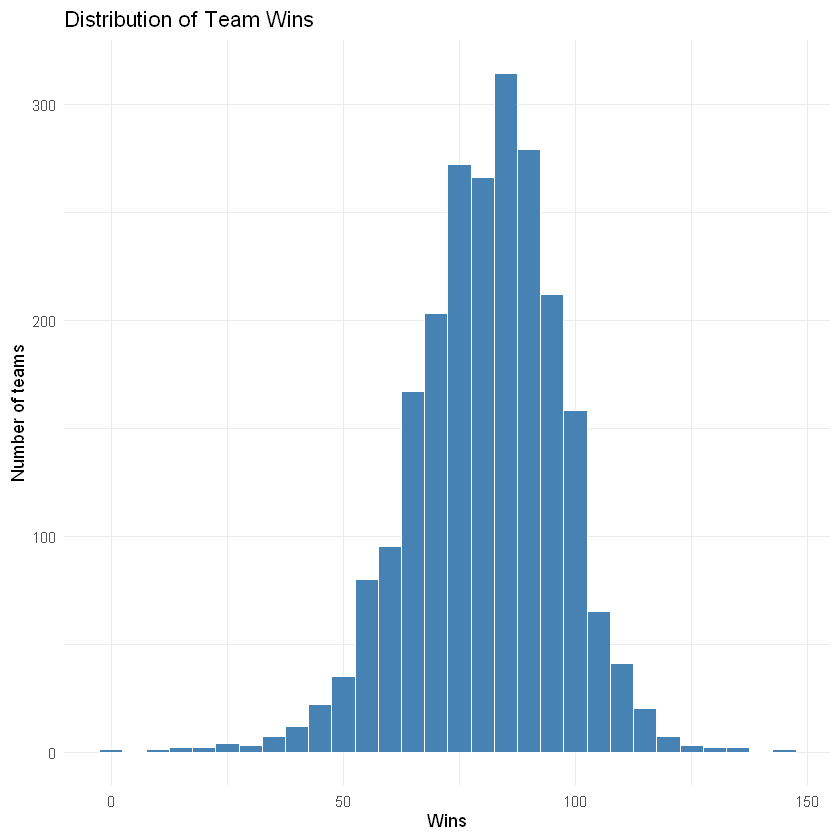

In [12]:
target_summary <- training %>%
  summarise(
    minimum = min(TARGET_WINS, na.rm = TRUE),
    first_quartile = quantile(TARGET_WINS, 0.25, na.rm = TRUE),
    median = median(TARGET_WINS, na.rm = TRUE),
    mean = mean(TARGET_WINS, na.rm = TRUE),
    third_quartile = quantile(TARGET_WINS, 0.75, na.rm = TRUE),
    maximum = max(TARGET_WINS, na.rm = TRUE)
  )

kable(target_summary)

ggplot(training, aes(x = TARGET_WINS)) +
  geom_histogram(binwidth = 5, fill = "steelblue", color = "white") +
  labs(
    title = "Distribution of Team Wins",
    x = "Wins",
    y = "Number of teams"
  ) +
  theme_minimal()